# Bootstrapped GMM PPN2V

The GMM parameterises `p(x|s)` as gaussians whose mean/variance are **polynomial functions of the signal**, so it fits a smooth Poisson-Gaussian-like trend and **extrapolates into the sparse high-signal region** where the histogram had no data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Cell 0: Initial Setup & Data Loading

In [ ]:
# Official successor repo: https://github.com/juglab/PPN2V  (adds the GMM noise model)
# IMPORTANT: PPN2V pins numpy<1.24, which would clash with Colab's numpy. We install it
# with --no-deps so numpy/torch are left as Colab provides them; the few numpy-2-removed
# calls in the repo are shimmed in Cell 1.

print("--- Installing PPN2V without disturbing numpy/torch... ---")
!pip install --quiet tifffile matplotlib scipy tqdm
!pip install --quiet --no-deps "git+https://github.com/juglab/PPN2V.git@3ea257dc5cf6587c036ee28422841ad8394325c7"

print("\n\n If the git install fails, clone + install --no-deps instead:")
print("   !git clone https://github.com/juglab/PPN2V.git /content/PPN2V && pip install -q --no-deps /content/PPN2V")
print("\n\n Installation complete. Please RESTART the session now (Runtime -> Restart session).")

--- Installing PPN2V without disturbing numpy/torch... ---
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


 If the git install fails, clone + install --no-deps instead:
   !git clone https://github.com/juglab/PPN2V.git /content/PPN2V && pip install -q --no-deps /content/PPN2V


 Installation complete. Please RESTART the session now (Runtime -> Restart session).


Cell 1: Imports, Paths & Configuration

In [ ]:
import os, sys, json, time, platform
import numpy as np
import tifffile
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torchvision

import torch.nn.init as _init
if not hasattr(_init, "xavier_normal"): _init.xavier_normal = _init.xavier_normal_
if not hasattr(_init, "constant"):      _init.constant     = _init.constant_

if not hasattr(np, "int"):      np.int = int                       # training.py: getStratifiedCoords2D
if not hasattr(np, "asscalar"): np.asscalar = lambda a: a.item()   # GMM .npz loader

import inspect as _inspect
import torch.optim.lr_scheduler as _lrs
if "verbose" not in _inspect.signature(_lrs.ReduceLROnPlateau.__init__).parameters:
    _RLROP = _lrs.ReduceLROnPlateau
    class _ReduceLROnPlateauCompat(_RLROP):
        def __init__(self, *a, **k):
            k.pop("verbose", None); super().__init__(*a, **k)
    _lrs.ReduceLROnPlateau = _ReduceLROnPlateauCompat

import torchvision.transforms.functional as _tvF
if not hasattr(_tvF, "to_tensor"):
    def _to_tensor(pic):
        arr = np.asarray(pic)
        if arr.ndim == 2: arr = arr[:, :, None]
        return torch.from_numpy(arr.transpose(2, 0, 1).copy()).float()
    _tvF.to_tensor = _to_tensor

from ppn2v.unet import UNet
from ppn2v.pn2v import utils, histNoiseModel, training, prediction
from ppn2v.pn2v.gaussianMixtureNoiseModel import GaussianMixtureNoiseModel

device = utils.getDevice()
print(f"Torch {torch.__version__} | Torchvision {torchvision.__version__} | NumPy {np.__version__} | Device: {device}")

def pad_to_divisible(image_stack, divisor=16):
    num_frames, h, w = image_stack.shape
    pad_h = (divisor - h % divisor) % divisor
    pad_w = (divisor - w % divisor) % divisor
    if pad_h == 0 and pad_w == 0: return image_stack, (0, 0, 0, 0)
    pad_top, pad_bottom = pad_h // 2, pad_h - (pad_h // 2)
    pad_left, pad_right = pad_w // 2, pad_w - (pad_w // 2)
    print(f"Padding HxW from {h}x{w} to {h+pad_h}x{w+pad_w}.")
    padded_stack = np.pad(image_stack, ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right)), mode='reflect')
    return padded_stack, (pad_top, pad_bottom, pad_left, pad_right)

def crop_padded_stack(padded_stack, spatial_pads):
    if not any(spatial_pads): return padded_stack
    pad_top, pad_bottom, pad_left, pad_right = spatial_pads
    h_new, w_new = padded_stack.shape[1], padded_stack.shape[2]
    crop_y_end = h_new - pad_bottom if pad_bottom > 0 else h_new
    crop_x_end = w_new - pad_right if pad_right > 0 else w_new
    return padded_stack[:, pad_top:crop_y_end, pad_left:crop_x_end]

def pad2d_reflect(img, divisor):
    h, w = img.shape
    ph = (divisor - h % divisor) % divisor
    pw = (divisor - w % divisor) % divisor
    t, b = ph // 2, ph - ph // 2
    l, r = pw // 2, pw - pw // 2
    return np.pad(img, ((t, b), (l, r)), mode='reflect'), (t, b, l, r)

def unpad2d(img, pads):
    t, b, l, r = pads
    H, W = img.shape
    return img[t:(H - b) if b > 0 else H, l:(W - r) if r > 0 else W]

# --- Configuration ---
CONFIG = {
    # --- Network / masking (PN2V defaults) ---
    "net_depth":            3,
    "num_samples":          800,
    "patch_size":           64,
    "n2v_perc_pix":         1.6,

    # --- Optimisation (shared by both training stages) ---
    "batch_size":           4,
    "virtual_batch_size":   20,
    "learning_rate":        1e-3,
    "val_size":             20,
    "augment":              True,

    # --- Stage 1: bootstrap N2V (used only to estimate the noise model) ---
    "bootstrap_epochs":     100,
    "bootstrap_steps":      20,

    # --- Stage 2: the PN2V network we benchmark ---
    "pn2v_epochs":          200,
    "pn2v_steps":           20,

    # --- GMM noise model (official PPN2V bootstrap recipe) ---
    "gmm_n_gaussian":       3,       # gaussians in the mixture
    "gmm_n_coeff":          2,       # polynomial order for param(signal): 2 = linear (best for extrapolation)
    "gmm_min_sigma":        25,      # variance floor (sigma floor = sqrt); raise if GMM training is unstable
    "gmm_epochs":           2000,    # official default
    "gmm_batch":            250000,  # official default
    "gmm_lr":               0.1,     # official default
    "gmm_sig_lo_pct":       0.5,     # signal percentile -> min_signal (normalisation + clip)
    "gmm_sig_hi_pct":       99.5,    # signal percentile -> max_signal

    # --- Misc ---
    "nm_bins":              128,     # bins for the comparison histogram / figure
    "nm_max_frames":        None,    # None -> ALL frames (better high-signal support for sparse spots)
    "val_fraction":         0.10,
    "save_prior_output":    True,
}


TRAIN_TIFF_PATH = "/content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif"
"""
TEST_TIFF_PATHS = [
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/30_Green/30_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/29_Green/29_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/20_Green/20_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/19_Green/19_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif"
]
"""
TEST_TIFF_PATHS = [
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_1.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_2.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_3.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_4.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_5.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_6.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_7.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_8.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_9.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_10.00.tif"
]

OUTPUT_DIR = "/content/drive/MyDrive/DATA_ROOT/exp_data3"
os.makedirs(OUTPUT_DIR, exist_ok=True)
PPN2V_MODEL_DIR = os.path.join(OUTPUT_DIR, "PPN2V_model")
os.makedirs(PPN2V_MODEL_DIR, exist_ok=True)
PAD_DIV = 2 ** (CONFIG["net_depth"] - 1)
print(f"Artifacts -> {PPN2V_MODEL_DIR}")

print(f"\nLoading TRAINING video from: {TRAIN_TIFF_PATH}")
try:
    training_frames = tifffile.imread(TRAIN_TIFF_PATH).astype(np.float32)
    if training_frames.ndim == 2:
        training_frames = training_frames[np.newaxis, ...]
    print(f" Loaded training stack: {training_frames.shape}")
except Exception as e:
    print(f" Error loading training TIFF: {e}")
    training_frames = None

CUDA available? True
Torch 2.11.0+cu128 | Torchvision 0.26.0+cu128 | NumPy 2.0.2 | Device: cuda
Artifacts -> /content/drive/MyDrive/DATA_ROOT/exp_data3/PPN2V_model

Loading TRAINING video from: /content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif
 Loaded training stack: (916, 256, 256)


Cell 2: Stage 1 — Bootstrap N2V network (identical to the PN2V notebook)

In [ ]:
if training_frames is None:
    print(" Training frames not found. Run Cell 1 first.")
else:
    N, H, W = training_frames.shape
    mult = 2 ** (CONFIG["net_depth"] - 1)
    ps = min(CONFIG["patch_size"], H, W); ps = (ps // mult) * mult
    assert ps >= mult, f"Images too small ({H}x{W}) for net_depth={CONFIG['net_depth']}."
    if ps != CONFIG["patch_size"]:
        print(f" Adjusted patch_size {CONFIG['patch_size']} -> {ps} to fit images / U-Net depth.")
    CONFIG["patch_size_effective"] = ps
    CONFIG["num_masked_pixels"] = int(round(ps * ps * CONFIG["n2v_perc_pix"] / 100.0))

    split = max(1, int(N * (1.0 - CONFIG["val_fraction"])))
    train_data = training_frames[:split].copy()
    val_data   = training_frames[split:].copy()
    if val_data.shape[0] == 0: val_data = training_frames[-1:].copy()
    print(f"Data split -> train: {train_data.shape}, val: {val_data.shape}")

    torch.manual_seed(0); np.random.seed(0)
    boot_net = UNet(1, depth=CONFIG["net_depth"])

    print("\n--- Training bootstrap N2V network (Stage 1)... ---")
    t0 = time.perf_counter()
    boot_train_hist, boot_val_hist = training.trainNetwork(
        net=boot_net, trainData=train_data, valData=val_data, noiseModel=None,
        postfix="ppn2v_bootstrap", directory=PPN2V_MODEL_DIR, device=device,
        numOfEpochs=CONFIG["bootstrap_epochs"], stepsPerEpoch=CONFIG["bootstrap_steps"],
        batchSize=CONFIG["batch_size"], patchSize=ps, numMaskedPixels=CONFIG["num_masked_pixels"],
        virtualBatchSize=CONFIG["virtual_batch_size"], valSize=CONFIG["val_size"],
        learningRate=CONFIG["learning_rate"], augment=CONFIG["augment"],
    )
    boot_time_s = time.perf_counter() - t0
    print(f" Bootstrap training done in {boot_time_s/60:.1f} min.")

    n_hist = N if CONFIG["nm_max_frames"] is None else min(N, CONFIG["nm_max_frames"])
    hist_idx = np.unique(np.linspace(0, N - 1, n_hist).astype(int))
    print(f"\n--- Estimating pseudo-clean signal on {len(hist_idx)} frames... ---")
    boot_net.train(False)
    obs_list, sig_list = [], []
    for k in tqdm(hist_idx):
        raw = training_frames[k]
        padded, pads = pad2d_reflect(raw, PAD_DIV)
        with torch.no_grad():
            means, _ = prediction.predict(padded, boot_net, None, device, outScaling=10.0)
        obs_list.append(raw); sig_list.append(unpad2d(means, pads))
    bootstrap_obs    = np.array(obs_list, dtype=np.float32)
    bootstrap_signal = np.array(sig_list, dtype=np.float32)
    print(f" Pseudo-clean signal ready: {bootstrap_signal.shape} "
          f"(range {bootstrap_signal.min():.0f}-{bootstrap_signal.max():.0f})")

Data split -> train: (824, 256, 256), val: (92, 256, 256)

--- Training bootstrap N2V network (Stage 1)... ---


/usr/local/lib/python3.12/dist-packages/ppn2v/unet/model.py:215: FutureWarning: `nn.init.xavier_normal` is now deprecated in favor of `nn.init.xavier_normal_`.
  init.xavier_normal(m.weight)
/usr/local/lib/python3.12/dist-packages/ppn2v/unet/model.py:216: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  init.constant(m.bias, 0)


Start training
Finished step 9/20      
Epoch 0 finished      
avg. loss: 1.0184782445430756+-(2SEM)0.07579097146204956      
Epoch time: 0.08198132912317911 min      
Epoch 1 finished      
avg. loss: 0.9560418367385864+-(2SEM)0.0474125328747957      
Epoch time: 0.06640225251515706 min      
Epoch 2 finished      
avg. loss: 0.9732926934957504+-(2SEM)0.09028179978883819      
Epoch time: 0.06752008199691772 min      
Epoch 3 finished      
avg. loss: 0.9279407769441604+-(2SEM)0.0904300370989925      
Epoch time: 0.06685701608657837 min      
Epoch 4 finished      
avg. loss: 0.8965189337730408+-(2SEM)0.0628471961596792      
Epoch time: 0.06609310309092203 min      
Finished step 109/20      
Epoch 5 finished      
avg. loss: 0.9021024525165557+-(2SEM)0.05165523201051158      
Epoch time: 0.06713972489039104 min      
Epoch 6 finished      
avg. loss: 0.9331077247858047+-(2SEM)0.06547462942613164      
Epoch time: 0.06565382083257039 min      
Epoch 7 finished      
avg. loss: 0.9048

  0%|          | 0/916 [00:00<?, ?it/s]

 Pseudo-clean signal ready: (916, 256, 256) (range 114-1431)


Cell 3: Build the GMM noise model  p(x|s)  (the difference from the histogram notebook)

GMM signal range: [182.9, 247.6]  (n_gaussian=3, n_coeff=2, min_sigma=25)

--- Training GMM noise model... ---
0 8.240511894226074
100 4.481925010681152
200 4.441465854644775
300 4.429716110229492
400 4.4322919845581055
500 4.427951335906982
600 4.424257755279541
700 4.424548149108887
800 4.427153587341309
900 4.426535129547119
1000 4.425339221954346
1100 4.427941799163818
1200 4.4253010749816895
1300 4.427086353302002
1400 4.424462795257568
1500 4.428404331207275
1600 4.427058696746826
1700 4.428197860717773
1800 4.424293041229248
1900 4.425919055938721

The trained parameters (GMMNoiseModel_cy3_3_2_bootstrap) is saved at location: /content/drive/MyDrive/DATA_ROOT/exp_data3/PPN2V_model/
 GMM trained in 1.71 min; saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PPN2V_model/GMMNoiseModel_cy3_3_2_bootstrap.npz


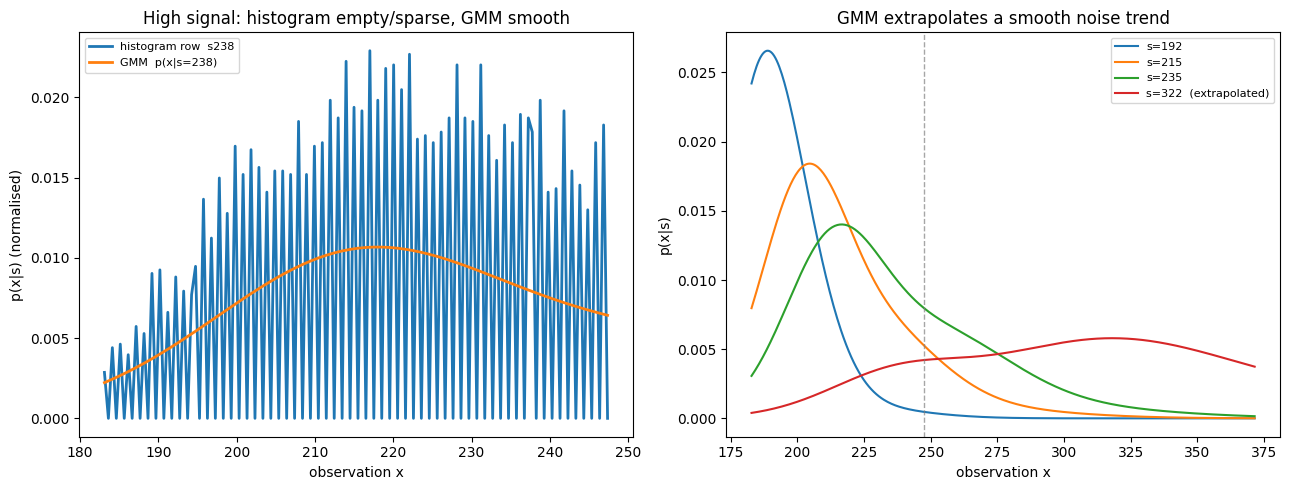

 GMM figure saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PPN2V_model/gmm_noise_model.png


In [ ]:
min_signal = float(np.percentile(bootstrap_signal, CONFIG["gmm_sig_lo_pct"]))
max_signal = float(np.percentile(bootstrap_signal, CONFIG["gmm_sig_hi_pct"]))
CONFIG["gmm_min_signal"], CONFIG["gmm_max_signal"] = min_signal, max_signal
print(f"GMM signal range: [{min_signal:.1f}, {max_signal:.1f}]  "
      f"(n_gaussian={CONFIG['gmm_n_gaussian']}, n_coeff={CONFIG['gmm_n_coeff']}, min_sigma={CONFIG['gmm_min_sigma']})")

gmm_name = f"GMMNoiseModel_cy3_{CONFIG['gmm_n_gaussian']}_{CONFIG['gmm_n_coeff']}_bootstrap"
gmm = GaussianMixtureNoiseModel(
    min_signal=min_signal, max_signal=max_signal, path=PPN2V_MODEL_DIR + os.sep,
    weight=None, n_gaussian=CONFIG["gmm_n_gaussian"], n_coeff=CONFIG["gmm_n_coeff"],
    device=device, min_sigma=CONFIG["gmm_min_sigma"],
)
print("\n--- Training GMM noise model... ---")
t0 = time.perf_counter()
gmm.train(bootstrap_signal, bootstrap_obs, batchSize=CONFIG["gmm_batch"],
          n_epochs=CONFIG["gmm_epochs"], learning_rate=CONFIG["gmm_lr"],
          name=gmm_name, lowerClip=CONFIG["gmm_sig_lo_pct"], upperClip=CONFIG["gmm_sig_hi_pct"])
gmm_time_s = time.perf_counter() - t0
gmm_npz = os.path.join(PPN2V_MODEL_DIR, gmm_name + ".npz")
noiseModel = gmm
print(f" GMM trained in {gmm_time_s/60:.2f} min; saved to {gmm_npz}")


bins = CONFIG["nm_bins"]
hist = histNoiseModel.createHistogram(bins, min_signal, max_signal, bootstrap_obs, bootstrap_signal)
obs_centers = (np.arange(bins) + 0.5) / bins * (max_signal - min_signal) + min_signal
obs_t = torch.from_numpy(obs_centers.astype(np.float32)).to(device)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sbin = int(0.85 * bins)
s_val = (sbin + 0.5) / bins * (max_signal - min_signal) + min_signal
hist_row = hist[0][sbin, :].astype(np.float64)
gmm_p = gmm.likelihood(obs_t, torch.tensor(float(s_val), device=device)).cpu().detach().numpy()
gmm_p = gmm_p / (gmm_p.sum() + 1e-12)
ax[0].plot(obs_centers, hist_row, label=f"histogram row  s{s_val:.0f}", lw=2)
ax[0].plot(obs_centers, gmm_p,  label=f"GMM  p(x|s={s_val:.0f})", lw=2)
ax[0].set_xlabel("observation x"); ax[0].set_ylabel("p(x|s) (normalised)")
ax[0].set_title("High signal: histogram empty/sparse, GMM smooth"); ax[0].legend(fontsize=8)

for s in [min_signal * 1.05, (min_signal + max_signal) / 2, max_signal * 0.95, max_signal * 1.3]:
    grid = np.linspace(min_signal, max_signal * 1.5, 400).astype(np.float32)
    gt = torch.from_numpy(grid).to(device)
    p = gmm.likelihood(gt, torch.tensor(float(s), device=device)).cpu().detach().numpy()
    tag = f"s={s:.0f}" + ("  (extrapolated)" if s > max_signal else "")
    ax[1].plot(grid, p, label=tag)
ax[1].axvline(max_signal, ls="--", color="grey", lw=1, alpha=0.7)
ax[1].set_xlabel("observation x"); ax[1].set_ylabel("p(x|s)")
ax[1].set_title("GMM extrapolates a smooth noise trend"); ax[1].legend(fontsize=8)
plt.tight_layout()
gmm_fig = os.path.join(PPN2V_MODEL_DIR, "gmm_noise_model.png")
plt.savefig(gmm_fig, dpi=150); plt.show()
print(f" GMM figure saved to {gmm_fig}")

Cell 4: Stage 2 — Train PPN2V (+ logs / config / specs / curves / time)

PPN2V (GMM) TRAINING LOG  |  2026-07-08 22:26:19
Start training
Finished step 9/20      
Epoch 0 finished      
avg. loss: 4.487430906295776+-(2SEM)0.015254324726370174      
Epoch time: 0.2742552320162455 min      
Epoch 1 finished      
avg. loss: 4.474718046188355+-(2SEM)0.027974652224087643      
Epoch time: 0.29708921909332275 min      
Epoch 2 finished      
avg. loss: 4.4396322011947635+-(2SEM)0.018124326414422312      
Epoch time: 0.299177086353302 min      
Epoch 3 finished      
avg. loss: 4.4753782749176025+-(2SEM)0.024575050224133067      
Epoch time: 0.29733774264653523 min      
Epoch 4 finished      
avg. loss: 4.491168570518494+-(2SEM)0.023029081814136744      
Epoch time: 0.29781380891799925 min      
Finished step 109/20      
Epoch 5 finished      
avg. loss: 4.5013285160064695+-(2SEM)0.03228997907594598      
Epoch time: 0.29708658854166664 min      
Epoch 6 finished      
avg. loss: 4.488255500793457+-(2SEM)0.02133433577292377      
Epoch time: 0.2950930039087931 m

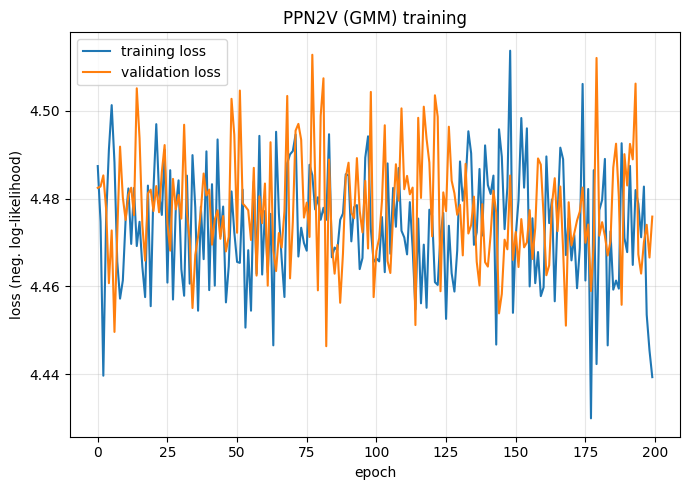

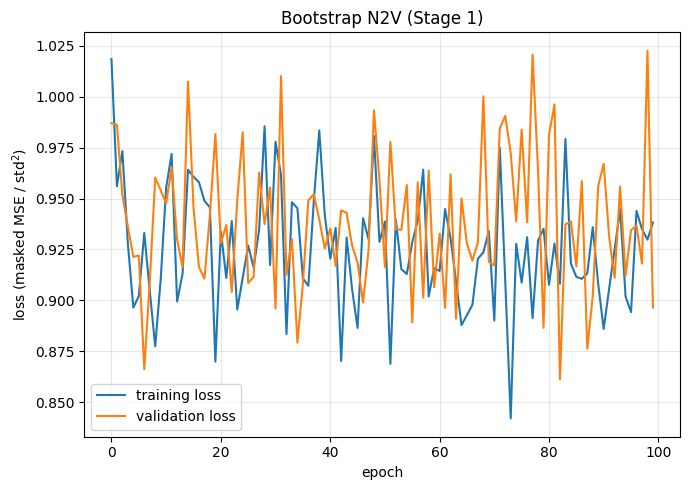

 Config + specs + timing saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PPN2V_model/ppn2v_run_config_and_specs.json
   GPU: NVIDIA A100-SXM4-80GB | total time: 67.25 min


In [ ]:
class _Tee:
    def __init__(self, *streams): self.streams = streams
    def write(self, data):
        for s in self.streams: s.write(data); s.flush()
    def flush(self):
        for s in self.streams: s.flush()

log_path = os.path.join(PPN2V_MODEL_DIR, "training_PPN2V.log")
log_file = open(log_path, "w"); _old = sys.stdout; sys.stdout = _Tee(_old, log_file)
try:
    print("=" * 70); print("PPN2V (GMM) TRAINING LOG  |  " + time.strftime("%Y-%m-%d %H:%M:%S")); print("=" * 70)
    torch.manual_seed(0); np.random.seed(0)
    ppn2v_net = UNet(CONFIG["num_samples"], depth=CONFIG["net_depth"])
    t0 = time.perf_counter()
    ppn2v_train_hist, ppn2v_val_hist = training.trainNetwork(
        net=ppn2v_net, trainData=train_data, valData=val_data, noiseModel=noiseModel,
        postfix="ppn2v", directory=PPN2V_MODEL_DIR, device=device,
        numOfEpochs=CONFIG["pn2v_epochs"], stepsPerEpoch=CONFIG["pn2v_steps"],
        batchSize=CONFIG["batch_size"], patchSize=CONFIG["patch_size_effective"],
        numMaskedPixels=CONFIG["num_masked_pixels"], virtualBatchSize=CONFIG["virtual_batch_size"],
        valSize=CONFIG["val_size"], learningRate=CONFIG["learning_rate"], augment=CONFIG["augment"],
    )
    ppn2v_time_s = time.perf_counter() - t0
    print(f"\n PPN2V training finished in {ppn2v_time_s/60:.1f} min ({len(ppn2v_train_hist)} epochs).")
finally:
    sys.stdout = _old; log_file.close()
print(f"Training log saved to {log_path}")

def _save_curves(tr, va, title, path, ylabel="loss (neg. log-likelihood)"):
    plt.figure(figsize=(7, 5))
    plt.plot(tr, label="training loss"); plt.plot(va, label="validation loss")
    plt.xlabel("epoch"); plt.ylabel(ylabel); plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.show()

_save_curves(ppn2v_train_hist, ppn2v_val_hist, "PPN2V (GMM) training",
             os.path.join(PPN2V_MODEL_DIR, "training_curves_PPN2V.png"))
_save_curves(boot_train_hist, boot_val_hist, "Bootstrap N2V (Stage 1)",
             os.path.join(PPN2V_MODEL_DIR, "training_curves_bootstrapN2V.png"),
             ylabel="loss (masked MSE / std$^2$)")

def _versions(pkgs):
    out = {}
    try:
        import importlib.metadata as md
        for p in pkgs:
            try: out[p] = md.version(p)
            except Exception: out[p] = None
    except Exception: pass
    return out

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
specs = {
    "method": "PPN2V (PN2V + Gaussian-Mixture noise model, Prakash et al. 2020)",
    "implementation": "official juglab/PPN2V @ 3ea257dc5cf6587c036ee28422841ad8394325c7",
    "noise_model": {
        "type": "gaussian_mixture (bootstrapped)",
        "construction": "Stage-1 N2V (UNet(1)) pseudo-clean signal vs. raw observations",
        "n_gaussian": CONFIG["gmm_n_gaussian"], "n_coeff": CONFIG["gmm_n_coeff"],
        "min_sigma": CONFIG["gmm_min_sigma"],
        "signal_range": [CONFIG["gmm_min_signal"], CONFIG["gmm_max_signal"]],
        "gmm_epochs": CONFIG["gmm_epochs"], "gmm_batch": CONFIG["gmm_batch"], "gmm_lr": CONFIG["gmm_lr"],
        "npz": gmm_npz, "num_pair_frames": int(bootstrap_obs.shape[0]),
    },
    "data": {"train_tiff": TRAIN_TIFF_PATH, "train_stack_shape": list(map(int, training_frames.shape)),
             "train_frames": int(train_data.shape[0]), "val_frames": int(val_data.shape[0])},
    "hyperparameters": CONFIG,
    "training_time": {
        "bootstrap_n2v_minutes": round(boot_time_s / 60, 2),
        "gmm_minutes": round(gmm_time_s / 60, 2),
        "ppn2v_minutes": round(ppn2v_time_s / 60, 2),
        "total_minutes": round((boot_time_s + gmm_time_s + ppn2v_time_s) / 60, 2),
    },
    "hardware": {"gpu": gpu_name, "cuda": torch.version.cuda, "cudnn": torch.backends.cudnn.version(),
                 "platform": platform.platform(), "python": platform.python_version()},
    "versions": _versions(["torch", "torchvision", "numpy", "tifffile", "scipy", "matplotlib"]),
    "final_losses": {
        "ppn2v_train_last": float(ppn2v_train_hist[-1]) if len(ppn2v_train_hist) else None,
        "ppn2v_val_last":   float(ppn2v_val_hist[-1])   if len(ppn2v_val_hist)   else None,
        "ppn2v_val_best":   float(np.min(ppn2v_val_hist)) if len(ppn2v_val_hist) else None,
    },
    "checkpoints": {"best": os.path.join(PPN2V_MODEL_DIR, "best_ppn2v.net"),
                    "last": os.path.join(PPN2V_MODEL_DIR, "last_ppn2v.net"),
                    "history_npy": os.path.join(PPN2V_MODEL_DIR, "historyppn2v.npy"), "gmm_npz": gmm_npz},
}
specs_path = os.path.join(PPN2V_MODEL_DIR, "ppn2v_run_config_and_specs.json")
with open(specs_path, "w") as f: json.dump(specs, f, indent=2)
np.save(os.path.join(PPN2V_MODEL_DIR, "ppn2v_train_hist.npy"), np.array(ppn2v_train_hist))
np.save(os.path.join(PPN2V_MODEL_DIR, "ppn2v_val_hist.npy"),   np.array(ppn2v_val_hist))
print(f" Config + specs + timing saved to {specs_path}")
print(f"   GPU: {gpu_name} | total time: {specs['training_time']['total_minutes']} min")

Cell 5: Denoise the test videos with PPN2V

In [ ]:
if 'TEST_TIFF_PATHS' in globals():
    print("\n--- Starting PPN2V Testing ---")
    if 'noiseModel' not in globals():
        params = np.load(os.path.join(PPN2V_MODEL_DIR, gmm_name + ".npz"))
        noiseModel = GaussianMixtureNoiseModel(params=params, device=device)

    best_ckpt = os.path.join(PPN2V_MODEL_DIR, "best_ppn2v.net")
    net = torch.load(best_ckpt, map_location=device, weights_only=False)
    net.to(device); net.train(False)
    print(f"Loaded model: {best_ckpt}")
    PAD_DIV = 2 ** (CONFIG["net_depth"] - 1)

    for test_path in TEST_TIFF_PATHS:
        try:
            print(f"\nProcessing: {os.path.basename(test_path)}")
            test_frames = tifffile.imread(test_path).astype(np.float32)
            if test_frames.ndim == 2: test_frames = test_frames[np.newaxis, ...]
            base = os.path.splitext(os.path.basename(test_path))[0]
        except Exception as e:
            print(f"  -> ERROR: could not load {test_path}. Skipping.\n   {e}"); continue

        padded, pads = pad_to_divisible(test_frames, divisor=PAD_DIV)
        print("  -> Denoising frames...")
        mmse_stack, prior_stack = [], []
        for frame in tqdm(padded):
            with torch.no_grad():
                means, mseEst = prediction.predict(frame, net, noiseModel, device, outScaling=10.0)
            mmse_stack.append(mseEst); prior_stack.append(means)

        mmse = crop_padded_stack(np.array(mmse_stack, dtype=np.float32), pads)
        out_path = os.path.join(OUTPUT_DIR, f"{base}_denoised_PPN2V.tif")
        tifffile.imwrite(out_path, np.clip(mmse, 0, 65535).astype(np.uint16), imagej=True)
        print(f"  ->  PPN2V (MMSE) saved to: {out_path}")

        if CONFIG["save_prior_output"]:
            prior = crop_padded_stack(np.array(prior_stack, dtype=np.float32), pads)
            prior_path = os.path.join(OUTPUT_DIR, f"{base}_denoised_PPN2V-prior.tif")
            tifffile.imwrite(prior_path, np.clip(prior, 0, 65535).astype(np.uint16), imagej=True)
            print(f"  -> (prior / N2V-like) saved to: {prior_path}")
else:
    print(" Test file paths not defined. Run Cell 1 first.")


--- Starting PPN2V Testing ---
Loaded model: /content/drive/MyDrive/DATA_ROOT/exp_data3/PPN2V_model/best_ppn2v.net

Processing: sim_Gauss_Poisson_Est_scale_1.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PPN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_1.00_denoised_PPN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_1.00_denoised_PPN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_2.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PPN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_2.00_denoised_PPN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_2.00_denoised_PPN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_3.00.tif
  -> Denoising frames...


...

  ->  PPN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_8.00_denoised_PPN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_8.00_denoised_PPN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_9.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PPN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_9.00_denoised_PPN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_9.00_denoised_PPN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_10.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PPN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_10.00_denoised_PPN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_10.00_denoised_PPN2V-prior.tif


### Notes

Outputs: (checkpoints `best/last_ppn2v.net`, `history*.npy`, `training_curves_PPN2V.png`, `training_PPN2V.log`, `ppn2v_run_config_and_specs.json`, `GMMNoiseModel_*.npz`, `gmm_noise_model.png`). Denoised videos: `*_denoised_PPN2V.tif`.
